In [1]:
import matplotlib.pyplot as plt
import pennylane as qml
import torch
from Dressed_Quantum_Net import DressedQuantumNetwork

In [2]:
qml.drawer.use_style("black_white")

In [3]:
RATING_TYPE = 'implicit'  # 'explicit' or 'implicit'
config = {'alias': 'qvc_neumf',
                'num_epoch': 10,                    # original 100, less now because an epoch takes 40 min for implicit NeuMF
                'batch_size': 256,                  # original 256
                'optimizer': 'adam',                # original 'adam'
                'adam_lr': 1e-3,                    # original 0.001
                'num_users': None,                  # to be set after loading data
                'num_items': None,                  # to be set after loading data
                'latent_dim_mf': 8,                 # original 8
                'latent_dim_mlp': 8,                # original 8
                'num_negative': 4,                  # original 4
                'layers': [16, 64, 32, 16, 8],      # layers[0] is the concat of latent user vector & latent item vector, this is what they used in the og paper too
                'l2_regularization': 0.0000001,     # original 0
                'weight_init_gaussian': True,
                'use_cuda': True,
                'use_bachify_eval': True,
                'device_id': 0,
                'pretrain': False,
                'pretrain_neumf_dir': r"checkpoints\1_implicit_ml1m_Epoch99_HR0.6776_NDCG0.4098.model",
                'model_dir': 'checkpoints/{}_Epoch{}_HR{:.4f}_NDCG{:.4f}.model',
                'are_ratings_explicit': RATING_TYPE == 'explicit',
                'n_qubits': 4,                   # Ideally, config['layers'][-1] + config['latent_dim_mf'] but this consumes too much VRAM
                'q_depth': 6,                       # Number of variational layers
                'q_delta': 0.01                     # Initial spread of random quantum weights
                }

In [4]:
dqn = DressedQuantumNetwork(config)

In [5]:
import numpy as np

### 1st option
>https://pennylane.ai/qml/demos/tutorial_quantum_transfer_learning/#variational-quantum-circuit

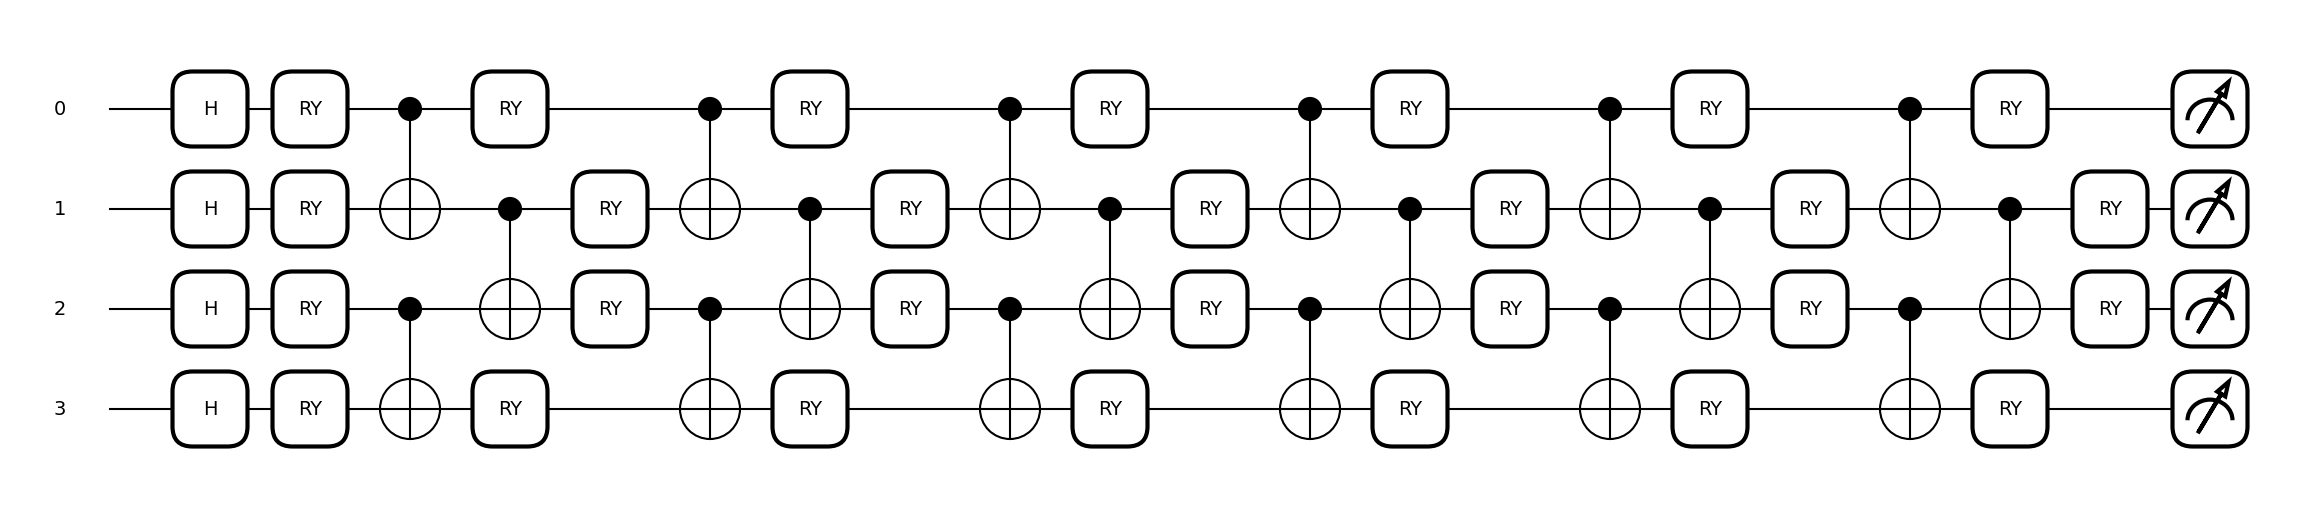

In [10]:
q_input_features = torch.rand(config['n_qubits'])
q_weights_flat = torch.rand(config['q_depth'] * config['n_qubits'])

fig, ax = qml.draw_mpl(dqn.quantum_net)(q_input_features, q_weights_flat)

### 2nd option: `pennylane.StronglyEntanglingLayers`

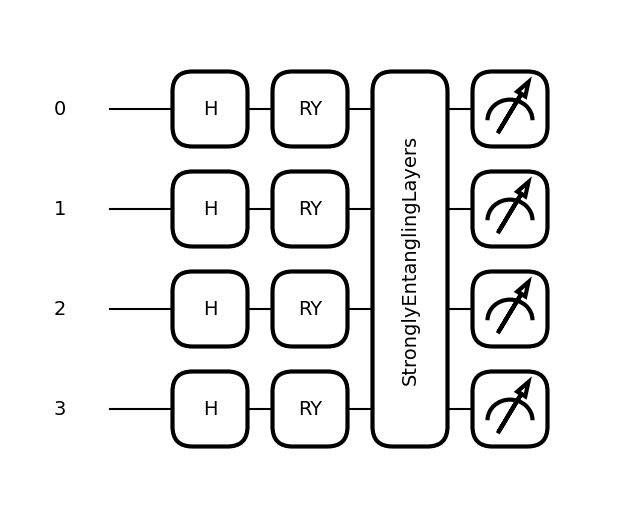

In [6]:
num_params = config["q_depth"] * config["n_qubits"] * 3
q_params = torch.nn.Parameter(config['q_delta'] * torch.randn(num_params))
q_input_features = torch.rand(config['n_qubits'])

fig, ax = qml.draw_mpl(dqn.strongly_entangling_layers)(q_input_features, q_params)